# 第9回 FTQC編 第1回「守る」演習ノートブック

**量子コンピューティング I / 情報工学科3年**

このノートブックは**一本の連続した実験記録**です。カーネルを途中で閉じず、上から順に
実行してください。スライドの「ノートブック: Cell N」という参照は、このノートブックのコードセル
冒頭にある `# ===== NB Cell N =====` と対応しています。**セルの並び順はスライドの
登場順と同じ**なので、上から順に進めればスライドと歩調が合います。

このノートブックは**単体でも読んで学べる**ように、各ステップに解説を付けています。

---

### この回を貫く問い
> 守りたい量子情報に *触れずに*、誤りだけを捕まえて直すには?

### 実験の地図(スライドのパート構成と一致)
| パート | このノートブックでやること | 実験 |
|---|---|---|
| 2 符号を作る | 3量子ビット符号 → Shor 9量子ビット符号 → break-even | 実験1–5 |
| 3 動かす | Shor に誤りを注入 → 捕まえる → 直す → 表引き | 実験6–9 |

### 前提知識
- 線形代数(ベクトル・行列・テンソル積)、確率、Python は既習
- 量子の最小限: 量子ビットの状態 \(a|0\rangle + b|1\rangle\)、測定で \(|0\rangle\) か \(|1\rangle\) に
  確率 \(|a|^2, |b|^2\) で潰れること、パウリ行列 \(X, Y, Z\)、回転ゲート \(R_x(\theta)\)
- 物理の知識は不要(すべてベクトルと行列の操作として扱う)

### ツール
Qiskit を中心に、補助として scipy(break-even 交差点の数値計算)と pylatexenc(回路図の描画)を
使います。未導入の環境では、最初のセルのコメントにある `pip install` を一度実行してください。
実機やノイズモデルは使わず、状態ベクトルとスタビライザの期待値で
「理屈通りに動くこと」を確認します(9量子ビット+補助なので状態ベクトルで十分)。

## 0. セットアップ

必要なライブラリを import します。`AerSimulator` はこの教材では明示的には使わず、
状態ベクトル (`Statevector`) と演算子 (`Operator`, `Pauli`) で計算します。

In [1]:
# ===== NB Cell 1 : import とセットアップ =====
# 未導入の環境では、次の行のコメントを外して一度実行してください(Qiskit 本体 + 補助 2 つ):
# %pip install qiskit scipy pylatexenc matplotlib
%matplotlib inline
import numpy as np
from math import comb
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Operator, Pauli

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(20260609)   # 乱数の種を固定(再現性のため)
print("Qiskit ready. 乱数シード固定済み。")

Qiskit ready. 乱数シード固定済み。


## 実験1 — 3量子ビット符号(スライド 2-5a に対応)

### 何をするか
古典の繰り返し符号 \(0\to000,\ 1\to111\) の量子版を作ります。

$$a|0\rangle + b|1\rangle \;\longrightarrow\; a|000\rangle + b|111\rangle$$

### なぜコピーではないのか(重要)
もしコピーなら \((a|0\rangle+b|1\rangle)^{\otimes 3}\) になるはずですが、そうではありません。
\(a|000\rangle + b|111\rangle\) では **係数 \(a,b\) は全体で1組**。\(|0\rangle\) を \(|000\rangle\) に、
\(|1\rangle\) を \(|111\rangle\) に置き換えただけで、3つの量子ビットは互いに**もつれて**います。
これが No-cloning 定理に違反しない理由です(決まった基底状態の冗長化は許される)。

### 回路
守りたい量子ビット \(q_0\) を制御に、2つの \(|0\rangle\) を標的とする **CNOT 2つ**だけです。

In [2]:
# ===== NB Cell 2 : 3量子ビット符号化 (CNOT 2つ) =====
def encode_3qubit(qc, q):
    # q[0] を制御に CNOT 2つ。 a|0>+b|1>  ->  a|000>+b|111>
    qc.cx(q[0], q[1])
    qc.cx(q[0], q[2])

# テスト用に一般の状態 a|0>+b|1> を q[0] に用意する (a=cos, b=sin)
theta_state = 1.0
a, b = np.cos(theta_state), np.sin(theta_state)

q = QuantumRegister(3, "q")
qc = QuantumCircuit(q)
qc.ry(2 * theta_state, q[0])      # |0> -> a|0> + b|1>
encode_3qubit(qc, q)

print("符号化回路:")
print(qc.draw(output="text"))

sv = Statevector.from_instruction(qc)
print(f"\n用意した係数:  a = {a:.4f},  b = {b:.4f}")
print(f"|000> の振幅 = {sv.data[0].real:.4f}   (a と一致するはず)")
print(f"|111> の振幅 = {sv.data[7].real:.4f}   (b と一致するはず)")
other = np.max(np.abs(np.delete(sv.data, [0, 7])))
print(f"それ以外の基底の最大振幅 = {other:.1e}  (0 のはず)")

符号化回路:
     ┌───────┐          
q_0: ┤ Ry(2) ├──■────■──
     └───────┘┌─┴─┐  │  
q_1: ─────────┤ X ├──┼──
              └───┘┌─┴─┐
q_2: ──────────────┤ X ├
                   └───┘

用意した係数:  a = 0.5403,  b = 0.8415
|000> の振幅 = 0.5403   (a と一致するはず)
|111> の振幅 = 0.8415   (b と一致するはず)
それ以外の基底の最大振幅 = 0.0e+00  (0 のはず)


**読み取り**: \(a|000\rangle + b|111\rangle\) がそのまま出ました。線形性のおかげで
\(a\) の項(\(|0\rangle\to|000\rangle\))と \(b\) の項(\(|1\rangle\to|111\rangle\))が独立に
処理されています。

## 実験2 — 関係だけを測る:パリティ測定(スライド 2-6 に対応)

### 何をするか
「状態 \(a,b\) に触れずに、誤りだけを測る」を具体化します。

正しい符号語では3つのビットは全部同じ値(000 か 111)です。だから
**「1番目と2番目は同じ値か?」「2番目と3番目は同じ値か?」** だけを訊けば、どこが反転
したか分かります。この「同じか?」は \(Z_1Z_2,\ Z_2Z_3\) というパリティで、**補助量子ビット**
を使って測れます。

### なぜ状態が壊れないか
この問いは \(a,b\) の値を一切訊いていません。「1番目と2番目は同じ?」は \(a\) が大きいか
\(b\) が大きいかに関係なく答えられる。だから測定しても重ね合わせ \(a|000\rangle+b|111\rangle\)
は壊れません。古典シンドローム \(He\) が「符号語の中身を消して誤りだけ残した」のと同じです。

下では回路の形だけ示します(深入りはしません)。

In [3]:
# ===== NB Cell 3 : パリティ測定回路 (補助qubit, Z1Z2/Z2Z3) =====
# 補助量子ビット 2つを使ったパリティ測定回路 (形を見るだけ)
data = QuantumRegister(3, "data")
anc  = QuantumRegister(2, "anc")
cb   = ClassicalRegister(2, "syndrome")
pc = QuantumCircuit(data, anc, cb)

# anc[0] <- Z1Z2 のパリティ (data0 と data1 が同じ値か)
pc.cx(data[0], anc[0])
pc.cx(data[1], anc[0])
# anc[1] <- Z2Z3 のパリティ (data1 と data2 が同じ値か)
pc.cx(data[1], anc[1])
pc.cx(data[2], anc[1])
pc.measure(anc[0], cb[0])
pc.measure(anc[1], cb[1])

print("パリティ測定回路:")
print(pc.draw(output="text"))
print("\n補助ビットの測定結果 (00)=反転なし、(01)/(10)/(11) で反転位置が分かる")

パリティ測定回路:
                                      
    data_0: ──■───────────────────────
              │                       
    data_1: ──┼────■────■─────────────
              │    │    │             
    data_2: ──┼────┼────┼───────■─────
            ┌─┴─┐┌─┴─┐  │  ┌─┐  │     
     anc_0: ┤ X ├┤ X ├──┼──┤M├──┼─────
            └───┘└───┘┌─┴─┐└╥┘┌─┴─┐┌─┐
     anc_1: ──────────┤ X ├─╫─┤ X ├┤M├
                      └───┘ ║ └───┘└╥┘
syndrome: 2/════════════════╩═══════╩═
                            0       1 

補助ビットの測定結果 (00)=反転なし、(01)/(10)/(11) で反転位置が分かる


## 実験3 — Shor の9量子ビット符号(スライド 2-9 に対応)

### 片手落ち → 両手
3量子ビット符号は**ビット反転 X しか直せません**(位相反転 Z には反応しない、片手落ち)。
1995年、Peter Shor は片手落ちの符号を**向きを変えて2段重ねる**ことでこれを解きました。

$$|0\rangle_L = \tfrac{1}{2\sqrt2}(|000\rangle+|111\rangle)(|000\rangle+|111\rangle)(|000\rangle+|111\rangle)$$
$$|1\rangle_L = \tfrac{1}{2\sqrt2}(|000\rangle-|111\rangle)(|000\rangle-|111\rangle)(|000\rangle-|111\rangle)$$

- **内側**(各3ビットブロック)でビット反転 X を訂正
- **外側**(3ブロック間の \(\pm\))で位相反転 Z を訂正

規格化係数は \(1/(2\sqrt2)\approx 0.3536\)。各論理状態は8つの基底に均等に広がります。

### このセルが「本番」
**ここで作る Shor 符号の状態 `sv_0L` を、この後 実験5・6 でそのまま使い回します**
(符号化し直しません)。これが「パート2で作った Shor に誤りを注入する」(スライド3-1)の実体です。

### 回路
外側=ブロック先頭への CNOT 2つ、各ブロック先頭に H、内側=各ブロックで CNOT 2つ。

In [4]:
# ===== NB Cell 4 : Shor 9量子ビット符号化 (入れ子) =====
def shor_encode(qc, q):
    # q[0..8] を使い、q[0] を符号化する。 a|0>+b|1> -> Shor 符号語。
    # --- 外側: ブロック先頭へ分配 (ブロック間のビット反転符号化) ---
    qc.cx(q[0], q[3])
    qc.cx(q[0], q[6])
    # --- 位相: 各ブロック先頭に H (+/- の重ね合わせを作る) ---
    for head in (q[0], q[3], q[6]):
        qc.h(head)
    # --- 内側: 各ブロックで先頭を3ビットに展開 ---
    for head in (0, 3, 6):
        qc.cx(q[head], q[head + 1])
        qc.cx(q[head], q[head + 2])

# |0> を符号化して |0>_L を確認する (a=1, b=0)
q = QuantumRegister(9, "q")
qc0 = QuantumCircuit(q)
shor_encode(qc0, q)
sv_0L = Statevector.from_instruction(qc0)

print("Shor 符号化回路:")
print(qc0.draw(output="text"))

probs = {format(i, "09b"): abs(sv_0L.data[i])**2
         for i in range(512) if abs(sv_0L.data[i]) > 1e-9}
print(f"\n|0>_L の非ゼロ基底数 = {len(probs)} 個 (理論値 8)")
print(f"各基底の確率 = {1/8:.4f} (= 1/8、振幅 1/(2*sqrt2) = {1/(2*np.sqrt(2)):.4f})")
for k, v in sorted(probs.items()):
    print(f"  |{k}>  prob={v:.4f}")

Shor 符号化回路:
               ┌───┐          
q_0: ──■────■──┤ H ├──■────■──
       │    │  └───┘┌─┴─┐  │  
q_1: ──┼────┼───────┤ X ├──┼──
       │    │       └───┘┌─┴─┐
q_2: ──┼────┼────────────┤ X ├
     ┌─┴─┐  │  ┌───┐     └───┘
q_3: ┤ X ├──┼──┤ H ├──■────■──
     └───┘  │  └───┘┌─┴─┐  │  
q_4: ───────┼───────┤ X ├──┼──
            │       └───┘┌─┴─┐
q_5: ───────┼────────────┤ X ├
          ┌─┴─┐┌───┐     └───┘
q_6: ─────┤ X ├┤ H ├──■────■──
          └───┘└───┘┌─┴─┐  │  
q_7: ───────────────┤ X ├──┼──
                    └───┘┌─┴─┐
q_8: ────────────────────┤ X ├
                         └───┘

|0>_L の非ゼロ基底数 = 8 個 (理論値 8)
各基底の確率 = 0.1250 (= 1/8、振幅 1/(2*sqrt2) = 0.3536)
  |000000000>  prob=0.1250
  |000000111>  prob=0.1250
  |000111000>  prob=0.1250
  |000111111>  prob=0.1250
  |111000000>  prob=0.1250
  |111000111>  prob=0.1250
  |111111000>  prob=0.1250
  |111111111>  prob=0.1250


**読み取り**: 8つの基底に均等(各確率 0.125、振幅 \(1/2\sqrt2\approx0.3536\))に広がった、
もつれた状態です。8個の生成子を暗記する必要はありません。持ち帰るのは構造一つ
——「片手落ちの符号を2段重ねると両手になる」。

## 実験4 — 誤りを測る道具:スタビライザ (stabilizer)

Shor 符号の誤りは、8個の**スタビライザ**の符号(\(\pm1\))で読みます。状態 \(a,b\) には触れず、
誤りの情報だけが出てきます。

- **Z型 6個**(\(Z_iZ_{i+1}\)、各ブロック内): ビット反転 X を検出
- **X型 2個**(ブロックをまたぐ \(X\cdots X\)): 位相反転 Z を検出

ここでは理想測定として、スタビライザの期待値から \(\pm1\) を読みます。単一パウリ誤りなら
状態はスタビライザの固有状態なので、期待値は厳密に \(\pm1\) になります(\(+1\)=正常)。

In [5]:
# ===== NB Cell 5 : スタビライザの定義とシンドローム関数 =====
# スタビライザを q0 順の文字列で書く (Pauli には左右反転して渡す)
STAB_Z = ["ZZIIIIIII", "IZZIIIIII",      # block 0 内
          "IIIZZIIII", "IIIIZZIII",      # block 1 内
          "IIIIIIZZI", "IIIIIIIZZ"]      # block 2 内
STAB_X = ["XXXXXXIII", "IIIXXXXXX"]      # ブロック間
STAB = STAB_Z + STAB_X

# 期待値計算を速くするため演算子行列を前計算しておく
_ops = [Operator(Pauli(s[::-1])).data for s in STAB]

def syndrome(sv):
    # 状態ベクトルから 8 個のスタビライザの符号 (+1/-1) を読む。+1=正常。
    out = []
    for M in _ops:
        ev = np.real(np.vdot(sv.data, M @ sv.data))
        out.append(int(round(ev)))
    return tuple(out)

print("スタビライザ (8個):")
for i, s in enumerate(STAB):
    kind = "Z型(ビット反転検出)" if i < 6 else "X型(位相反転検出)"
    print(f"  g{i+1}: {s}   {kind}")
print("\n誤りなしのシンドローム (全て +1 のはず):")
print(" ", syndrome(sv_0L))

スタビライザ (8個):
  g1: ZZIIIIIII   Z型(ビット反転検出)
  g2: IZZIIIIII   Z型(ビット反転検出)
  g3: IIIZZIIII   Z型(ビット反転検出)
  g4: IIIIZZIII   Z型(ビット反転検出)
  g5: IIIIIIZZI   Z型(ビット反転検出)
  g6: IIIIIIIZZ   Z型(ビット反転検出)
  g7: XXXXXXIII   X型(位相反転検出)
  g8: IIIXXXXXX   X型(位相反転検出)

誤りなしのシンドローム (全て +1 のはず):
  (1, 1, 1, 1, 1, 1, 1, 1)


## 実験5 — 符号は本当に得か:break-even(スライド 2-12 / 2-13 / 2-13b に対応)

### 言葉を揃える:θ から p へ
連続回転 \(R_x(\theta)\) の誤りは、測定の瞬間に確率 \(p=\sin^2(\theta/2)\) で X 誤りに化けます
(パート1の式。実験8 で実際に確かめます)。この \(p\) で性能を比べます。

### 2つの曲線
- **裸**の量子ビット: 論理誤り率 \(p_L = p\)(両対数で傾き1)
- **Shor 符号化**: 1個までの誤りを直せるので、**2個以上**同時に誤って初めて失敗。
  素朴な上界で \(p_L \approx A\,p^2\)、\(A=\binom{9}{2}=36\)(9個から2個を選ぶ場合の数、傾き2)

\(A=36\) は **Shor 9量子ビット基準**です(3量子ビットの \(A=\binom{3}{2}=3\) ではありません)。
9個使ったぶん「誤る場所」も増えています。

### モンテカルロ(自分で誤りを撒く)
各 \(p\) について「確率 \(p\) で各量子ビットに X を撒く → シンドロームを測る → 表引きで
訂正する → 論理エラーが起きたか判定」を数百回くり返し、論理誤り率を数えます。

> **正直な注**: \(A p^2\) は「2個以上誤ったら必ず失敗」と仮定した**上界**です。また、この実験の
> 論理エラー判定(\(|0\rangle_L\) との重なり)は**論理 Z を完全には数えない楽観側**の数え方で、
> 実機の論理誤り率はこれよりやや高めに出ます。読み方は「実測点が**上界の下に、傾き 2 で並ぶ**」
> まで。比較用に、誤りが 0 個または 1 個までなら成功とする二項モデルの曲線も参考に重ねます。
> 物語(数%で break-even、9個使ったコスト)は変わりません。

In [6]:
# ===== NB Cell 6 : break-even 解析 (A=36, 交差点) =====
A = comb(9, 2)
print(f"A = C(9,2) = {A}  (Shor 9量子ビット基準)")

# --- 交差点 (break-even) を2つの見方で出す ---
p_be_naive = 1.0 / A                       # 素朴上界: A p^2 = p -> p = 1/A
theta_be = np.rad2deg(2 * np.arcsin(np.sqrt(p_be_naive)))
print(f"break-even (素朴上界 A*p^2=p):  p* = 1/A = {p_be_naive:.4f}  (およそ {p_be_naive*100:.1f}%)")
print(f"  対応する角度 theta = およそ {theta_be:.0f} 度")

def p_logical_binomial(p):
    # 0個 or 1個の誤り以外を失敗とする二項モデル (縮退無視の素朴モデル)
    return 1 - (1 - p)**9 - 9 * p * (1 - p)**8

from scipy.optimize import brentq
p_be_binom = brentq(lambda p: p_logical_binomial(p) - p, 1e-4, 0.5)
theta_be_binom = np.rad2deg(2 * np.arcsin(np.sqrt(p_be_binom)))
print(f"break-even (二項モデル):        p* = {p_be_binom:.4f}  (およそ {p_be_binom*100:.1f}%)")
print(f"  対応する角度 theta = およそ {theta_be_binom:.0f} 度")
print("\n=> いずれも『数パーセント程度』。正確な交差点ではなく概算の桁として扱う。")

A = C(9,2) = 36  (Shor 9量子ビット基準)
break-even (素朴上界 A*p^2=p):  p* = 1/A = 0.0278  (およそ 2.8%)
  対応する角度 theta = およそ 19 度


break-even (二項モデル):        p* = 0.0323  (およそ 3.2%)
  対応する角度 theta = およそ 21 度

=> いずれも『数パーセント程度』。正確な交差点ではなく概算の桁として扱う。


In [7]:
# ===== NB Cell 7 : break-even モンテカルロ (Shor, N=2000) =====
# X誤りの表引き辞書を作る: Z型6シンドローム -> 反転した位置
XT = {}
for i in range(9):
    c = QuantumCircuit(9); c.x(i)
    XT[syndrome(sv_0L.evolve(c))[:6]] = i

def monte_carlo_trial(p):
    # 確率 p で各 qubit に X を撒き、訂正後に論理エラーかどうかを返す
    flips = [i for i in range(9) if rng.random() < p]
    c = QuantumCircuit(9)
    for i in flips:
        c.x(i)
    sv = sv_0L.evolve(c)
    zsyn = syndrome(sv)[:6]
    # 表引き訂正 (単一X仮定。複数誤りなら誤推定もありうる)
    c2 = QuantumCircuit(9)
    if any(v == -1 for v in zsyn):
        j = XT.get(zsyn)
        if j is not None:
            c2.x(j)
    sv_c = sv.evolve(c2)
    # 論理エラー判定: |0>_L との重なりが小さければ論理反転とみなす
    return abs(np.vdot(sv_0L.data, sv_c.data))**2 < 0.5

ps = np.array([0.005, 0.01, 0.02, 0.028, 0.04, 0.06, 0.10, 0.15, 0.20])
N = 2000
pL_mc = np.array([np.mean([monte_carlo_trial(p) for _ in range(N)]) for p in ps])

print(f"モンテカルロ (各 p で {N} 回):")
print(f"{'p':>7} {'MC p_L':>9} {'裸 p':>7} {'A*p^2(上界)':>12}")
for p, pl in zip(ps, pL_mc):
    print(f"{p:7.3f} {pl:9.4f} {p:7.3f} {A*p**2:12.4f}")

モンテカルロ (各 p で 2000 回):
      p    MC p_L     裸 p    A*p^2(上界)
  0.005    0.0000   0.005       0.0009
  0.010    0.0005   0.010       0.0036
  0.020    0.0120   0.020       0.0144
  0.028    0.0195   0.028       0.0282
  0.040    0.0410   0.040       0.0576
  0.060    0.0830   0.060       0.1296
  0.100    0.1745   0.100       0.3600
  0.150    0.3345   0.150       0.8100
  0.200    0.4685   0.200       1.4400


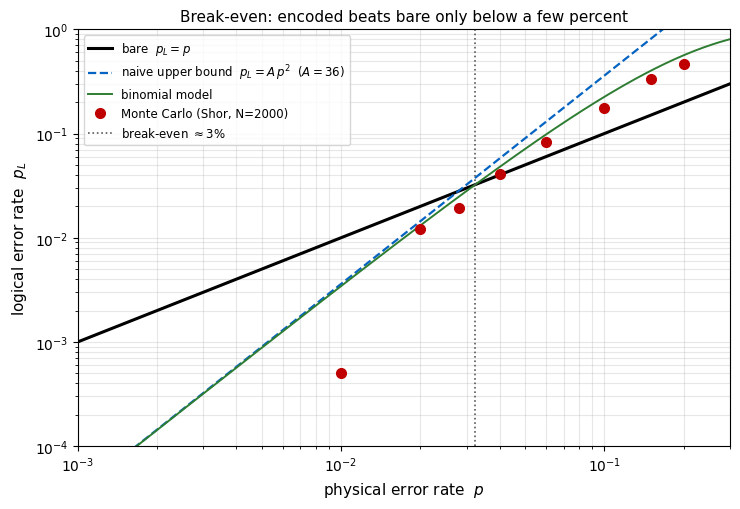

自分で撒いた点 (赤) が、解析上界の下に傾き 2 で並ぶ。
小 p では符号化が裸より下=得、break-even(約3%)超で裸を上回る=損。


In [8]:
# ===== NB Cell 8 : break-even プロット出力 =====
# break-even プロット (スライドに貼る図と同一)
pp = np.logspace(-3, np.log10(0.3), 200)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.loglog(pp, pp, "k-", lw=2.2, label=r"bare  $p_L=p$")
ax.loglog(pp, A * pp**2, "--", color="#0563C1", lw=1.6,
          label=rf"naive upper bound  $p_L=A\,p^2$  ($A={A}$)")
ax.loglog(pp, p_logical_binomial(pp), "-", color="#2E7D32", lw=1.4, label="binomial model")
ax.loglog(ps, np.maximum(pL_mc, 5e-5), "o", color="#C00000", ms=7,
          label=f"Monte Carlo (Shor, N={N})")
ax.axvline(p_be_binom, color="#595959", ls=":", lw=1.2,
           label=rf"break-even $\approx${p_be_binom*100:.0f}%")
ax.set_xlabel("physical error rate  $p$", fontsize=11)
ax.set_ylabel("logical error rate  $p_L$", fontsize=11)
ax.set_xlim(1e-3, 0.3); ax.set_ylim(1e-4, 1)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("Break-even: encoded beats bare only below a few percent", fontsize=11)
plt.tight_layout()
plt.savefig("breakeven.png", dpi=120, bbox_inches="tight")
plt.show()
print("自分で撒いた点 (赤) が、解析上界の下に傾き 2 で並ぶ。")
print("小 p では符号化が裸より下=得、break-even(約3%)超で裸を上回る=損。")

---

> **ここでスライドのパート2が終わり、パート3に入ります。** ノートブックは閉じません
> —— **実験3 で作った Shor 符号 `sv_0L` を、このまま使い続けます**。

---

## 実験6 — 誤りを入れて、捕まえて、直す(スライド 3-1 に対応)

### 何をするか
実験3 で作った Shor 符号 `sv_0L` に、わざと単一のパウリ誤り(X / Z / Y)を1個入れて、
シンドロームから位置を特定し、訂正して**忠実度が 1.0 に戻る**ことを確認します。

### 訂正のしくみ
- **X訂正(ビット反転)**: Z型6シンドロームが反転位置を一意に教える → そこに X をかけ直す
- **Z訂正(位相反転)**: X型2シンドロームがどのブロックかを教える → そのブロックの代表に Z

Y = XZ なので、X訂正と Z訂正の両方が効けば Y も直せます(両手の符号)。

In [9]:
# ===== NB Cell 9 : 誤り注入 -> シンドローム -> 訂正 -> 忠実度 =====
# Z誤りの表引き: X型2シンドローム -> ブロック代表 (ブロック先頭) に Z
ZT = {}
for i in range(9):
    c = QuantumCircuit(9); c.z(i)
    xsyn = syndrome(sv_0L.evolve(c))[6:]
    ZT.setdefault(xsyn, (i // 3) * 3)

def correct(sv):
    # シンドロームを読んで X訂正(表引き)と Z訂正(ブロック代表)を施した状態を返す
    syn = syndrome(sv)
    zsyn6, xsyn2 = syn[:6], syn[6:]
    c = QuantumCircuit(9)
    if any(v == -1 for v in zsyn6):            # ビット反転
        j = XT.get(zsyn6)
        if j is not None:
            c.x(j)
    if any(v == -1 for v in xsyn2):            # 位相反転
        k = ZT.get(xsyn2)
        if k is not None:
            c.z(k)
    return sv.evolve(c)

print("単一誤りの注入 -> 訂正 -> 忠実度:")
print(f"{'誤り':>6} {'シンドローム (8 generators)':>32} {'忠実度':>9}")
for kind in ["X", "Z", "Y"]:
    for i in [0, 4, 8]:
        c = QuantumCircuit(9)
        getattr(c, kind.lower())(i)
        sv_err = sv_0L.evolve(c)
        syn = syndrome(sv_err)
        sv_cor = correct(sv_err)
        f = state_fidelity(sv_0L, sv_cor)
        print(f"{kind}{i:>5}  {str(syn):>32}  {f:9.4f}")

単一誤りの注入 -> 訂正 -> 忠実度:
    誤り            シンドローム (8 generators)       忠実度
X    0         (-1, 1, 1, 1, 1, 1, 1, 1)     1.0000
X    4        (1, 1, -1, -1, 1, 1, 1, 1)     1.0000
X    8         (1, 1, 1, 1, 1, -1, 1, 1)     1.0000
Z    0         (1, 1, 1, 1, 1, 1, -1, 1)     1.0000
Z    4        (1, 1, 1, 1, 1, 1, -1, -1)     1.0000
Z    8         (1, 1, 1, 1, 1, 1, 1, -1)     1.0000
Y    0        (-1, 1, 1, 1, 1, 1, -1, 1)     1.0000
Y    4      (1, 1, -1, -1, 1, 1, -1, -1)     1.0000
Y    8        (1, 1, 1, 1, 1, -1, 1, -1)     1.0000


**読み取り**: X・Z・Y のどれを1個入れても、訂正後の忠実度は **1.0**。
ビット反転も位相反転も、その両方が重なった誤り(Y)も直せています。

## 実験7 — 誤り注入の回路を図で見る(スライド 3-1 の回路図)

スライドに貼る「符号化 → 誤り注入 → 測定」の回路図を出します。ここでは Shor 符号化の後に
\(q_0\) へ単一 X を注入した回路を描きます。

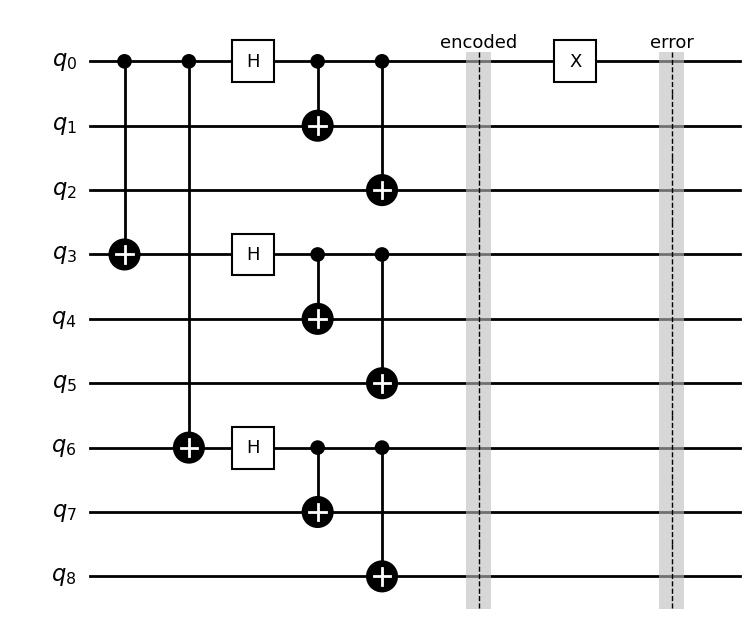

符号化(CNOT/H の入れ子) -> barrier -> q0 に X 注入。
この後シンドロームを測ると Z型1番目が -1 になり、q0 の反転と分かる。


In [10]:
# ===== NB Cell 10 : 誤り注入回路の図 =====
# Shor 符号化 + q0 に X 注入 + スタビライザ測定の一部 を回路図で
qfull = QuantumRegister(9, "q")
qc_inject = QuantumCircuit(qfull)
shor_encode(qc_inject, qfull)
qc_inject.barrier(label="encoded")
qc_inject.x(qfull[0])                       # 誤り注入 (例: q0 に X)
qc_inject.barrier(label="error")

fig = qc_inject.draw(output="mpl", fold=-1, style={"name": "bw"})
fig.savefig("circuit_inject.png", dpi=110, bbox_inches="tight")
plt.show()
print("符号化(CNOT/H の入れ子) -> barrier -> q0 に X 注入。")
print("この後シンドロームを測ると Z型1番目が -1 になり、q0 の反転と分かる。")

## 実験8 — 連続誤り \(R_x(\theta)\) が測定で離散化される(スライド 3-1b に対応)

### パート1の核心を数値で
連続的にかけた \(R_x(\theta)\) 誤りが、シンドローム測定の瞬間に「誤りなし(I)」か
「X誤り」かに**パチンと確定(collapse)**します。X に化ける確率は \(\sin^2(\theta/2)\)。

\(\theta\) を振って、シンドローム測定の射影確率が \(\sin^2(\theta/2)\) と一致するか確かめます。

In [11]:
# ===== NB Cell 11 : R_x(theta) collapse 確率 =====
# q0 に R_x(theta) をかけた後、スタビライザ Z0Z1 が -1 (=X誤り側) になる射影確率
M_proj = (np.eye(512) - _ops[0]) / 2   # スタビライザ ZZIIIIIII の固有値 -1 への射影演算子

def x_collapse_prob(theta_deg):
    th = np.deg2rad(theta_deg)
    c = QuantumCircuit(9); c.rx(th, 0)
    sv = sv_0L.evolve(c)
    return np.real(np.vdot(sv.data, M_proj @ sv.data))

print(f"{'theta(deg)':>11} {'P(X collapse)':>15} {'sin^2(theta/2)':>16}")
thetas = [10, 20, 30, 45, 60, 90]
measured, theory = [], []
for d in thetas:
    pm = x_collapse_prob(d)
    pt = np.sin(np.deg2rad(d)/2)**2
    measured.append(pm); theory.append(pt)
    print(f"{d:11d} {pm:15.4f} {pt:16.4f}")

 theta(deg)   P(X collapse)   sin^2(theta/2)
         10          0.0076           0.0076
         20          0.0302           0.0302
         30          0.0670           0.0670
         45          0.1464           0.1464
         60          0.2500           0.2500
         90          0.5000           0.5000


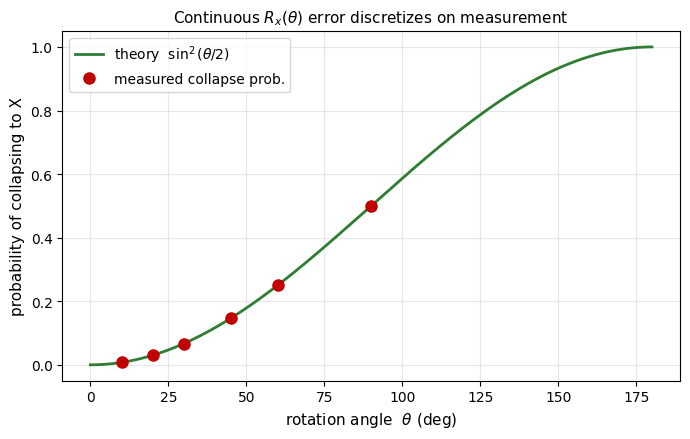

連続的にかけた誤りが、測定で『I か X』に畳まれる。確率は sin^2(theta/2) ちょうど。


In [12]:
# ===== NB Cell 12 : collapse プロット出力 =====
# θ スイープを図に (スライドに貼る図と同一)
dd = np.linspace(0, 180, 200)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dd, np.sin(np.deg2rad(dd)/2)**2, "-", color="#2E7D32", lw=2,
        label=r"theory  $\sin^2(\theta/2)$")
ax.plot(thetas, measured, "o", color="#C00000", ms=8, label="measured collapse prob.")
ax.set_xlabel(r"rotation angle  $\theta$ (deg)", fontsize=11)
ax.set_ylabel("probability of collapsing to X", fontsize=11)
ax.grid(True, alpha=0.3); ax.legend(fontsize=10)
ax.set_title(r"Continuous $R_x(\theta)$ error discretizes on measurement", fontsize=11)
plt.tight_layout(); plt.savefig("collapse.png", dpi=120, bbox_inches="tight")
plt.show()
print("連続的にかけた誤りが、測定で『I か X』に畳まれる。確率は sin^2(theta/2) ちょうど。")

**読み取り**: 測定の射影確率(赤点)が理論曲線 \(\sin^2(\theta/2)\)(緑)にぴったり乗ります。
連続誤りが測定で離散パウリに畳まれる、というパート1の主張が数値で確認できました。

## 実験9 — シンドローム → 誤り位置の表引き(スライド 3-2 に対応)

### Shor では推定が簡単
シンドロームのパターンと誤り位置がほぼ一対一です。表を引くように訂正先が決まります。
- **X誤り**: 9個すべて区別できる(Z型6シンドロームで一意)
- **Z誤り**: ブロックは分かるが、ブロック内の位置は区別しない(縮退。でもどれを直しても同じ)

### これが伏線
符号が大きくなると、この対応は崩れ、推定は「古典計算機が本気で解くグラフの問題」に
なります(最終回のデコーダ)。

In [13]:
# ===== NB Cell 13 : シンドローム表引き (X一意 / Z縮退) =====
print("=== X誤り (ビット反転): Z型6シンドロームで位置が一意に決まる ===")
print(f"{'誤り':>5}  {'Z型シンドローム (6)':>22}  -> 反転位置")
for i in range(9):
    c = QuantumCircuit(9); c.x(i)
    z6 = syndrome(sv_0L.evolve(c))[:6]
    print(f"  X{i:<2}  {str(z6):>22}  ->  qubit {XT[z6]}")

print("\n=== Z誤り (位相反転): X型2シンドロームでブロックは分かるが、")
print("    ブロック内の位置は区別されない (縮退。でもどれを直しても同じ) ===")
print(f"{'誤り':>5}  {'X型シンドローム (2)':>20}  -> ブロック")
groups = {}
for i in range(9):
    c = QuantumCircuit(9); c.z(i)
    x2 = syndrome(sv_0L.evolve(c))[6:]
    groups.setdefault(x2, []).append(f"Z{i}")
for x2, errs in sorted(groups.items()):
    print(f"  {str(x2):>20}  ->  block {ZT[x2]//3}  ({', '.join(errs)} が同じシンドローム)")

=== X誤り (ビット反転): Z型6シンドロームで位置が一意に決まる ===
   誤り            Z型シンドローム (6)  -> 反転位置
  X0      (-1, 1, 1, 1, 1, 1)  ->  qubit 0
  X1     (-1, -1, 1, 1, 1, 1)  ->  qubit 1
  X2      (1, -1, 1, 1, 1, 1)  ->  qubit 2
  X3      (1, 1, -1, 1, 1, 1)  ->  qubit 3
  X4     (1, 1, -1, -1, 1, 1)  ->  qubit 4
  X5      (1, 1, 1, -1, 1, 1)  ->  qubit 5
  X6      (1, 1, 1, 1, -1, 1)  ->  qubit 6
  X7     (1, 1, 1, 1, -1, -1)  ->  qubit 7
  X8      (1, 1, 1, 1, 1, -1)  ->  qubit 8

=== Z誤り (位相反転): X型2シンドロームでブロックは分かるが、
    ブロック内の位置は区別されない (縮退。でもどれを直しても同じ) ===
   誤り          X型シンドローム (2)  -> ブロック
              (-1, -1)  ->  block 1  (Z3, Z4, Z5 が同じシンドローム)
               (-1, 1)  ->  block 0  (Z0, Z1, Z2 が同じシンドローム)
               (1, -1)  ->  block 2  (Z6, Z7, Z8 が同じシンドローム)


**読み取り**: X誤りは9個すべて区別でき、Z誤りはブロックまで分かる(ブロック内は縮退)。
これで Shor 符号の「捕まえて直す」が一通り動きました。

---

## まとめ — このノートブックで自分の手で確かめたこと

| 実験 | 確かめたこと |
|---|---|
| 1 | 3量子ビット符号化(コピーではなく基底の冗長化) |
| 2 | パリティ測定が状態に触れず関係だけを訊く |
| 3 | Shor 9量子ビット符号(片手+片手=両手) |
| 4 | スタビライザでシンドロームを読む |
| 5 | break-even:符号は数%より良い土台でだけ得 |
| 6 | 単一 X/Y/Z を忠実度1.0で訂正 |
| 7 | 誤り注入回路の形 |
| 8 | 連続誤り \(R_x(\theta)\) が測定で離散化(\(\sin^2(\theta/2)\)) |
| 9 | シンドローム表引き(X一意 / Z縮退) |

今日のループ(符号化 → 誤り蓄積 → 測定 → 推定 → 訂正 → …)を1個、Shor という特定の
符号で回しました。次回は「どんな符号でも作れる」共通言語(スタビライザ形式)へ進みます。